In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import kstest
from statsmodels.tsa.stattools import adfuller, kpss
from pandas_datareader.data import DataReader

plt.style.use("default")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
from copulas import *

In [3]:
HAS_NDTEST = False

In [4]:
def get_fred_series(series, start, end):
    df = DataReader(series, "fred", start, end)
    return df

def get_vix_rvx(start, end):
    vix = get_fred_series("VIXCLS", start, end)
    rvx = get_fred_series("RVXCLS", start, end)

    df = pd.concat([vix, rvx], axis=1)
    df.columns = ["VIX", "RVX"]
    df = df.dropna()
    return df

In [5]:
def get_log_returns(prices):
    return np.log(prices).diff().dropna()

def get_simple_returns(prices):
    return prices.pct_change().dropna()

def growth_from_log_returns(log_returns):
    return np.exp(log_returns.cumsum())

def plot_prices(df, title="Prices"):
    ax = df.plot(figsize=(12, 6))
    ax.set_title(title)
    ax.grid(True)
    plt.show()

def plot_growth(log_returns, title="Growth of $1"):
    g = growth_from_log_returns(log_returns)
    ax = g.plot(figsize=(12, 6))
    ax.set_title(title)
    ax.grid(True)
    plt.show()

def plot_spread(spread, title="Spread"):
    ax = spread.plot(figsize=(12, 4))
    ax.set_title(title)
    ax.grid(True)
    plt.show()

def zscore(x, window):
    mu = x.rolling(window).mean()
    sd = x.rolling(window).std()
    return (x - mu) / sd

In [6]:
def fit_marginals(returns, tickers):
    dist_list = [
        (stats.norm, "Normal"),
        (stats.t, "Student_t"),
        (stats.genlogistic, "Logistic"),
        (stats.genextreme, "Extreme")
    ]

    all_rows = []
    best_rows = []

    for stock in tickers:
        x = returns[stock].dropna().values
        best_aic = np.inf
        best_item = None

        for dist, name in dist_list:
            params = dist.fit(x)
            fitted = dist(*params)

            pdf_vals = np.maximum(fitted.pdf(x), 1e-300)
            ll = np.sum(np.log(pdf_vals))
            k = len(params)

            aic = 2 * k - 2 * ll
            bic = k * np.log(len(x)) - 2 * ll
            ks_p = kstest(x, fitted.cdf).pvalue

            row = [stock, name, aic, bic, ks_p, params]
            all_rows.append(row)

            if aic < best_aic:
                best_aic = aic
                best_item = row

        best_rows.append(best_item)

    all_df = pd.DataFrame(
        all_rows,
        columns=["Series", "Distribution", "AIC", "BIC", "KS_pvalue", "Params"]
    )

    best_df = pd.DataFrame(
        best_rows,
        columns=["Series", "Distribution", "AIC", "BIC", "KS_pvalue", "Params"]
    )

    return all_df, best_df

In [7]:
def build_fitted_distribution(dist_name, params):
    if dist_name == "Normal":
        return stats.norm(*params)
    elif dist_name == "Student_t":
        return stats.t(*params)
    elif dist_name == "Logistic":
        return stats.genlogistic(*params)
    elif dist_name == "Extreme":
        return stats.genextreme(*params)
    else:
        raise ValueError(f"Distribution inconnue: {dist_name}")

def transform_to_uniforms(returns, best_marginals):
    series_names = best_marginals["Series"].tolist()
    fitted = {}

    for _, row in best_marginals.iterrows():
        fitted[row["Series"]] = build_fitted_distribution(row["Distribution"], row["Params"])

    u = fitted[series_names[0]].cdf(returns[series_names[0]].values)
    v = fitted[series_names[1]].cdf(returns[series_names[1]].values)

    u = np.clip(u, 1e-8, 1 - 1e-8)
    v = np.clip(v, 1e-8, 1 - 1e-8)

    return u, v, fitted

In [8]:
def fit_copula_family(u, v, copula_obj, name=None, method="cml"):
    cop = copula_obj

    try:
        if hasattr(cop, "fit"):
            if "method" in cop.fit.__code__.co_varnames:
                cop.fit(u, v, method=method)
            else:
                cop.fit(u, v)

        ll = cop.log_likelihood(u, v)
        k = getattr(cop, "num_params", 1)
        n = len(u)

        aic = 2 * k - 2 * ll
        bic = np.log(n) * k - 2 * ll

        out = {
            "Copula": name if name is not None else getattr(cop, "name", type(cop).__name__),
            "LogLik": ll,
            "AIC": aic,
            "BIC": bic,
            "Object": cop
        }

        if hasattr(cop, "rho"):
            out["Param"] = cop.rho
        elif hasattr(cop, "alpha"):
            out["Param"] = cop.alpha
        else:
            out["Param"] = np.nan

        return out

    except Exception as e:
        return {
            "Copula": name if name is not None else getattr(cop, "name", type(cop).__name__),
            "LogLik": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Object": None,
            "Param": np.nan,
            "Error": str(e)
        }


def fit_all_copulas(u, v, use_ndtest=False):
    families = [
        GaussianCopula(),
        ClaytonCopula(),
        GumbelCopula(),
        FrankCopula(),
        JoeCopula(),
        N13Copula(),
        N14Copula()
    ]

    rows = []
    for cop in families:
        row = fit_copula_family(u, v, cop, name=cop.name, method="cml")
        rows.append(row)

    df = pd.DataFrame(rows)

    if use_ndtest and HAS_NDTEST:
        ks_pvals = []
        energy_pvals = []

        for obj in df["Object"]:
            if obj is None:
                ks_pvals.append(np.nan)
                energy_pvals.append(np.nan)
                continue

            try:
                smp = obj.sample(size=len(u))
                ks_p = ndtest.ks2d2s(u, v, smp[:, 0], smp[:, 1])
                en_p, _, _ = ndtest.estat2d(u, v, smp[:, 0], smp[:, 1], nboot=300)
                ks_pvals.append(ks_p)
                energy_pvals.append(en_p)
            except Exception:
                ks_pvals.append(np.nan)
                energy_pvals.append(np.nan)

        df["KS2D_pvalue"] = ks_pvals
        df["Energy_pvalue"] = energy_pvals

    return df.sort_values("AIC")

In [9]:
def fit_best_marginals_on_window(window_returns):
    all_marg, best_marg = fit_marginals(window_returns, list(window_returns.columns))
    return all_marg, best_marg

def fit_best_copula_on_window(window_returns, use_ndtest=False):
    _, best_marg = fit_best_marginals_on_window(window_returns)
    u_fit, v_fit, fitted = transform_to_uniforms(window_returns, best_marg)
    copula_table = fit_all_copulas(u_fit, v_fit, use_ndtest=use_ndtest)
    best_row = copula_table.iloc[0]
    best_cop = best_row["Object"]
    return best_marg, fitted, copula_table, best_cop

def get_prob_trading(returns, fitting_period, predicting_period, start, end, use_ndtest=False):
    s1, s2 = returns.columns
    idx_all = returns.index
    idx_trade = returns.loc[start:end].index

    prob_s1 = []
    prob_s2 = []
    out_index = []
    chosen_copulas = []

    start_positions = np.arange(
        idx_all.get_loc(idx_trade[0]),
        idx_all.get_loc(idx_trade[-1]) + 1,
        predicting_period
    )

    for start_loc in start_positions:
        fit_ret = returns.iloc[start_loc - fitting_period:start_loc]
        pred_ret = returns.iloc[start_loc:min(start_loc + predicting_period, len(returns))]

        best_marg, fitted, copula_table, best_cop = fit_best_copula_on_window(
            fit_ret, use_ndtest=use_ndtest
        )

        if best_cop is None:
            continue

        u_pred = fitted[s1].cdf(pred_ret[s1].values)
        v_pred = fitted[s2].cdf(pred_ret[s2].values)

        u_pred = np.clip(u_pred, 1e-8, 1 - 1e-8)
        v_pred = np.clip(v_pred, 1e-8, 1 - 1e-8)

        chosen_name = copula_table.iloc[0]["Copula"]

        for dt, u, v in zip(pred_ret.index, u_pred, v_pred):
            if dt < pd.to_datetime(start) or dt > pd.to_datetime(end):
                continue

            try:
                p1 = best_cop.cdf_u_given_v(np.array([u]), np.array([v]))
                p2 = best_cop.cdf_v_given_u(np.array([u]), np.array([v]))

                if isinstance(p1, np.ndarray):
                    p1 = float(np.ravel(p1)[0])
                if isinstance(p2, np.ndarray):
                    p2 = float(np.ravel(p2)[0])

                prob_s1.append(p1)
                prob_s2.append(p2)
                out_index.append(dt)
                chosen_copulas.append(chosen_name)
            except Exception:
                continue

    probs = pd.DataFrame(
        {s1: prob_s1, s2: prob_s2, "BestCopula": chosen_copulas},
        index=pd.DatetimeIndex(out_index)
    )

    probs = probs[~probs.index.duplicated(keep="first")]
    return probs

In [10]:
def pair_strategy(log_returns, probs_trade, cl=0.90, cl_close=0.65):
    s1, s2 = [c for c in probs_trade.columns if c != "BestCopula"]

    positions = pd.DataFrame(0.0, index=probs_trade.index, columns=[s1, s2])

    long_open = False
    short_open = False

    for t in positions.index:
        p1 = probs_trade.loc[t, s1]
        p2 = probs_trade.loc[t, s2]

        # long s1 / short s2
        if long_open:
            if (p1 > (1 - cl_close)) or (p2 < cl_close):
                positions.loc[t] = [0, 0]
                long_open = False
            else:
                positions.loc[t] = [1, -1]

        # short s1 / long s2
        elif short_open:
            if (p1 < cl_close) or (p2 > (1 - cl_close)):
                positions.loc[t] = [0, 0]
                short_open = False
            else:
                positions.loc[t] = [-1, 1]

        else:
            if (p1 < (1 - cl)) and (p2 > cl):
                positions.loc[t] = [1, -1]
                long_open = True
            elif (p1 > cl) and (p2 < (1 - cl)):
                positions.loc[t] = [-1, 1]
                short_open = True
            else:
                positions.loc[t] = [0, 0]

    aligned_ret = log_returns.loc[positions.index]

    pair_log_ret = (aligned_ret * positions.shift(1).fillna(0.0)).sum(axis=1)

    pair_simple = np.exp(pair_log_ret) - 1.0
    s1_simple = np.exp(aligned_ret[s1]) - 1.0
    s2_simple = np.exp(aligned_ret[s2]) - 1.0

    equity = pd.DataFrame({
        "algo": (1 + pair_simple).cumprod(),
        s1: (1 + s1_simple).cumprod(),
        s2: (1 + s2_simple).cumprod()
    }, index=positions.index)

    return equity, positions, pair_simple

In [11]:
def calculate_metrics(cumret):
    cumret = pd.Series(cumret).dropna()

    total_return = cumret.iloc[-1] / cumret.iloc[0] - 1
    apr = (1 + total_return) ** (252 / len(cumret)) - 1

    daily = cumret.pct_change().dropna()
    sharpe = np.sqrt(252) * daily.mean() / daily.std(ddof=0) if daily.std(ddof=0) > 0 else np.nan

    hwm = cumret.cummax()
    dd = cumret / hwm - 1
    maxdd = dd.min()

    return pd.Series({
        "Total return": total_return,
        "APR": apr,
        "Sharpe": sharpe,
        "MaxDD": maxdd
    })

Head prices / levels:


,VIX,RVX
DATE,,
2010-01-04,20.04,26.55
2010-01-05,19.35,26.66
2010-01-06,19.16,25.64
2010-01-07,19.06,24.82
2010-01-08,18.13,23.55


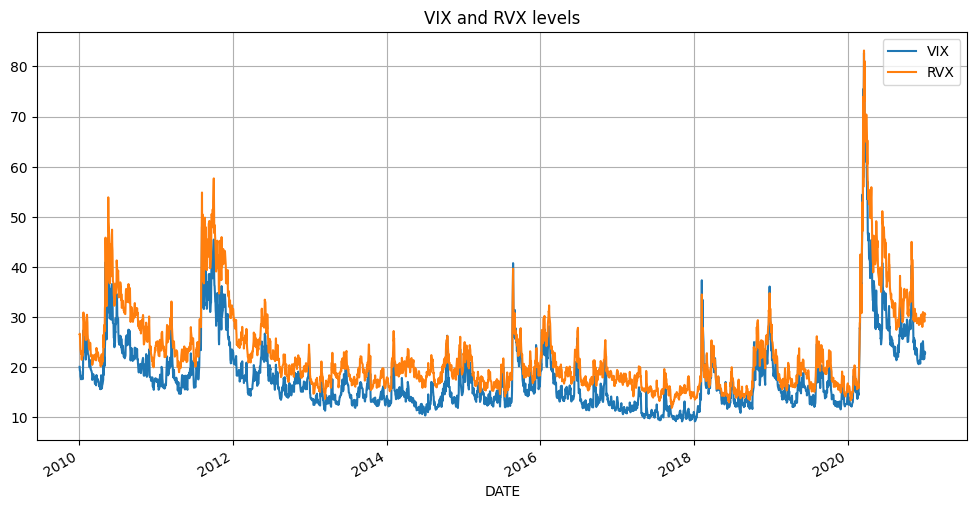

Head log returns:


,VIX,RVX
DATE,,
2010-01-05,-0.035038,0.004135
2010-01-06,-0.009868,-0.039011
2010-01-07,-0.005233,-0.032504
2010-01-08,-0.050024,-0.052524
2010-01-11,-0.032514,-0.041176


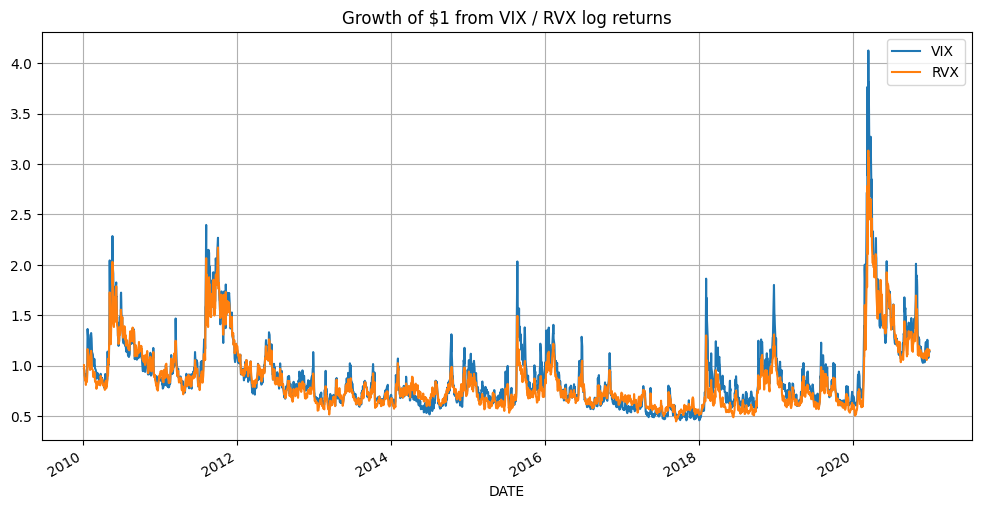

Correlation of log returns:


,VIX,RVX
VIX,1.000000,0.902986
RVX,0.902986,1.000000


Kendall tau: 0.6921431062634058


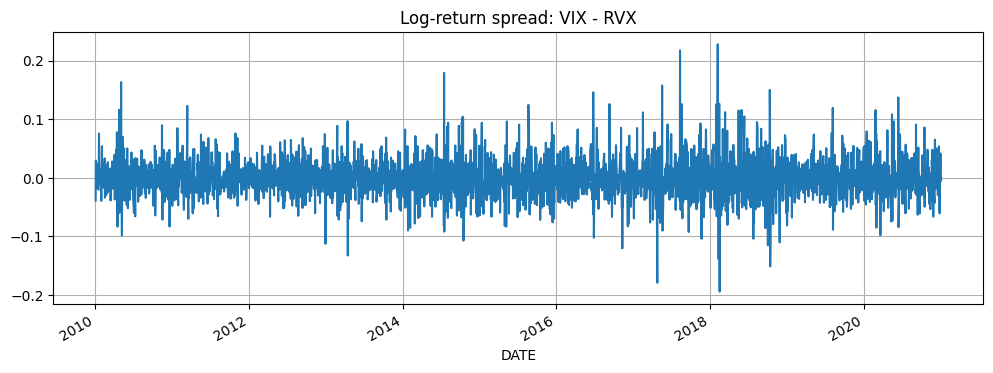

ADF p-value on spread: 2.443569100162182e-30
KPSS p-value on spread: 0.1


C:\Users\tawaj\AppData\Local\Temp\ipykernel_7688\223146924.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS p-value on spread:", kpss(spread_train.dropna(), regression="c", nlags="auto")[1])


In [12]:
train_start = "2010-01-01"
train_end   = "2020-12-31"

vol_train = get_vix_rvx(train_start, train_end)

print("Head prices / levels:")
display(vol_train.head())

plot_prices(vol_train, "VIX and RVX levels")

returns_train = get_log_returns(vol_train)

print("Head log returns:")
display(returns_train.head())

plot_growth(returns_train, "Growth of $1 from VIX / RVX log returns")

print("Correlation of log returns:")
display(returns_train.corr())

tau = stats.kendalltau(returns_train["VIX"], returns_train["RVX"])[0]
print("Kendall tau:", tau)

spread_train = returns_train["VIX"] - returns_train["RVX"]
plot_spread(spread_train, "Log-return spread: VIX - RVX")

print("ADF p-value on spread:", adfuller(spread_train.dropna())[1])
print("KPSS p-value on spread:", kpss(spread_train.dropna(), regression="c", nlags="auto")[1])

In [13]:
all_marginals, best_marginals = fit_marginals(returns_train, ["VIX", "RVX"])

print("All marginal fits:")
display(all_marginals.sort_values(["Series", "AIC"]))

print("Best marginal fits:")
display(best_marginals)

All marginal fits:


,Series,Distribution,AIC,BIC,KS_pvalue,Params
5,RVX,Student_t,-7967.956778,-7950.179137,1.112614e-01,"(4.007631395918217, -0.0036476681357737488, 0...."
6,RVX,Logistic,-7939.158634,-7921.380993,4.525997e-02,"(1.5115234406864575, -0.023025369980746082, 0...."
4,RVX,Normal,-7567.012021,-7555.160260,9.044184e-13,"(5.0580763042824625e-05, 0.06163443004949171)"
7,RVX,Extreme,-6980.016992,-6962.239351,4.114339e-127,"(0.12070243863707247, 0.00020510328935090602, ..."
1,VIX,Student_t,-6716.607914,-6698.830273,2.896611e-01,"(3.4727508251595007, -0.005410041677791225, 0...."
2,VIX,Logistic,-6608.768840,-6590.991199,4.190507e-07,"(0.987746498767573, 4.905944319313595e-05, 0.0..."
0,VIX,Normal,-6230.133909,-6218.282149,1.938463e-17,"(4.5821845802129846e-05, 0.07846940016034896)"
3,VIX,Extreme,-5771.360764,-5753.583123,6.809273e-133,"(0.10142094201070909, 0.00017778909902600411, ..."


Best marginal fits:


,Series,Distribution,AIC,BIC,KS_pvalue,Params
0,VIX,Student_t,-6716.607914,-6698.830273,0.289661,"(3.4727508251595007, -0.005410041677791225, 0...."
1,RVX,Student_t,-7967.956778,-7950.179137,0.111261,"(4.007631395918217, -0.0036476681357737488, 0...."


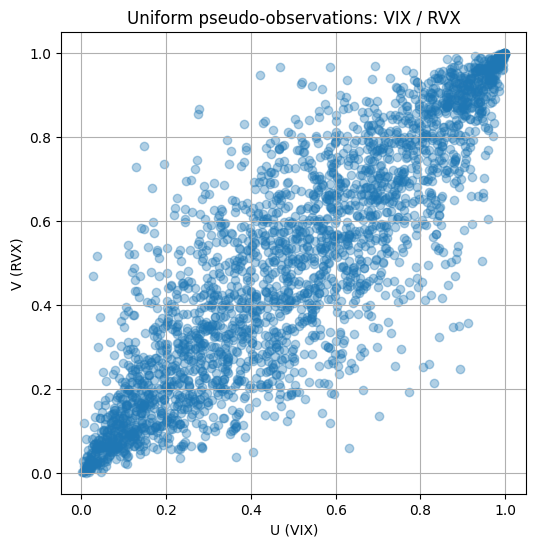

In [14]:
u, v, fitted_train = transform_to_uniforms(returns_train, best_marginals)

plt.figure(figsize=(6, 6))
plt.scatter(u, v, alpha=0.35)
plt.title("Uniform pseudo-observations: VIX / RVX")
plt.xlabel("U (VIX)")
plt.ylabel("V (RVX)")
plt.grid(True)
plt.show()

In [15]:
copula_table = fit_all_copulas(u, v, use_ndtest=HAS_NDTEST)

print("Copula comparison:")
display(copula_table[["Copula", "Param", "LogLik", "AIC", "BIC"] + ([c for c in ["KS2D_pvalue", "Energy_pvalue"] if c in copula_table.columns])])

best_copula_name = copula_table.iloc[0]["Copula"]
best_copula_obj = copula_table.iloc[0]["Object"]

print("Best copula selected:", best_copula_name)

Copula comparison:


,Copula,Param,LogLik,AIC,BIC
6,N14,2.725439,2248.024207,-4494.048415,-4488.122534
0,Gaussian,0.885336,2180.569322,-4359.138645,-4353.212764
2,Gumbel,3.143058,2160.927887,-4319.855774,-4313.929894
5,N13,7.870285,1971.917614,-3941.835228,-3935.909348
3,Frank,10.884979,1923.745169,-3845.490338,-3839.564458
4,Joe,3.777580,1844.106149,-3686.212298,-3680.286418
1,Clayton,3.159593,1743.725712,-3485.451424,-3479.525544


Best copula selected: N14


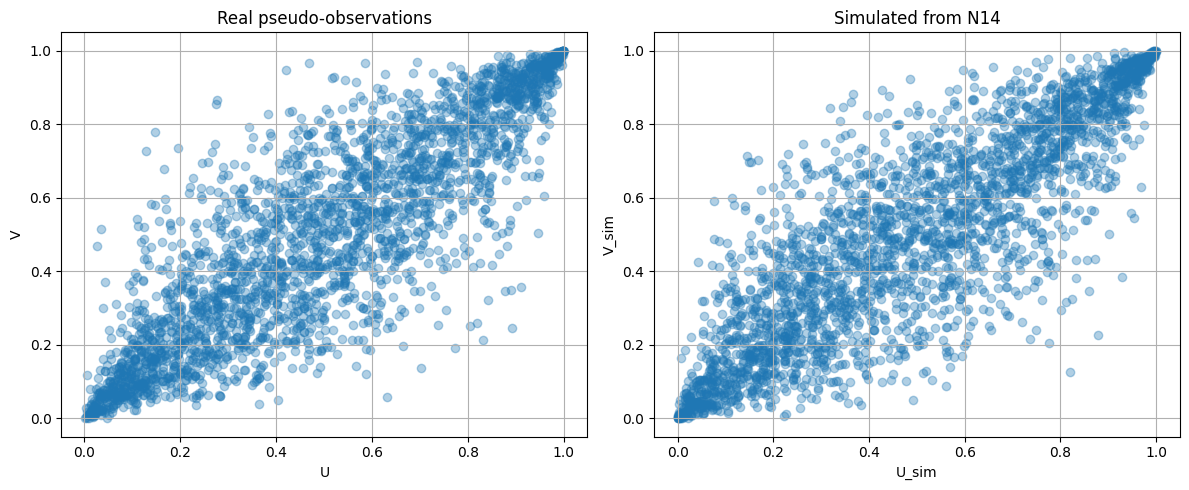

In [16]:
uv_sim = best_copula_obj.sample(size=len(u))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(u, v, alpha=0.35)
plt.title("Real pseudo-observations")
plt.xlabel("U")
plt.ylabel("V")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(uv_sim[:, 0], uv_sim[:, 1], alpha=0.35)
plt.title(f"Simulated from {best_copula_name}")
plt.xlabel("U_sim")
plt.ylabel("V_sim")
plt.grid(True)

plt.tight_layout()
plt.show()

Head full sample:


,VIX,RVX
DATE,,
2006-01-03,11.14,18.84
2006-01-04,11.37,18.49
2006-01-05,11.31,17.99
2006-01-06,11.00,17.26
2006-01-09,11.13,16.92


Tail full sample:


,VIX,RVX
DATE,,
2024-12-24,14.27,21.36
2024-12-26,14.73,21.64
2024-12-27,15.95,22.35
2024-12-30,17.40,23.59
2024-12-31,17.35,23.57


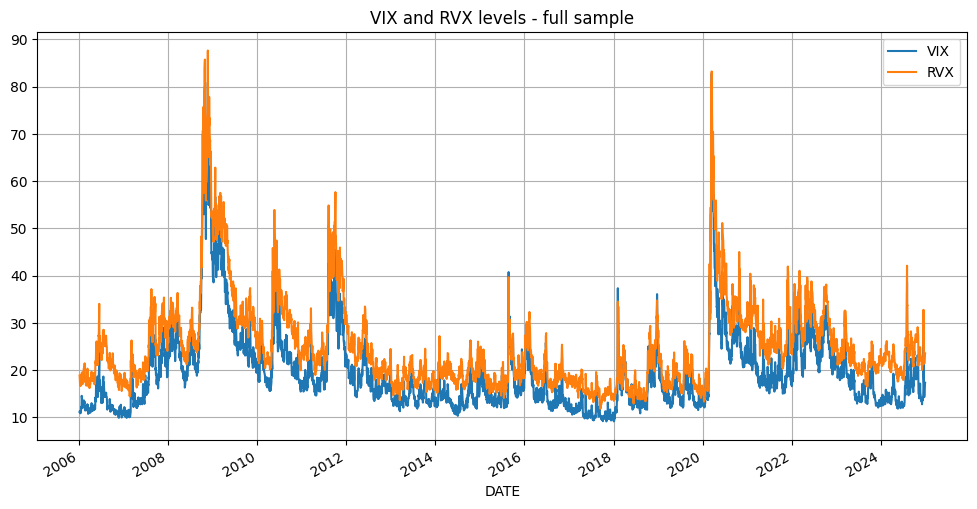

In [17]:
full_start = "2006-01-01"
full_end   = "2024-12-31"

vol_full = get_vix_rvx(full_start, full_end)
returns_full = get_log_returns(vol_full)

print("Head full sample:")
display(vol_full.head())

print("Tail full sample:")
display(vol_full.tail())

plot_prices(vol_full, "VIX and RVX levels - full sample")

In [18]:
fitting_period = 500
predicting_period = 100

trade_start = "2021-01-01"
trade_end   = "2025-12-31"

probs_trade = get_prob_trading(
    returns_full,
    fitting_period=fitting_period,
    predicting_period=predicting_period,
    start=trade_start,
    end=trade_end,
    use_ndtest=False
)

print("Conditional probabilities:")
display(probs_trade.head())

print("Best copulas frequency in rolling windows:")
display(probs_trade["BestCopula"].value_counts())

C:\Users\tawaj\copulas.py:28: RuntimeWarning: invalid value encountered in log
  return np.log(self.pdf(u,v)).sum()


Conditional probabilities:


,VIX,RVX,BestCopula
2021-01-04,0.758456,0.568319,Gaussian
2021-01-05,0.699691,0.160468,Gaussian
2021-01-06,0.345649,0.661526,Gaussian
2021-01-07,0.104649,0.715312,Gaussian
2021-01-08,0.000721,0.999661,Gaussian


Best copulas frequency in rolling windows:


BestCopula
Gaussian    605
N14         400
Name: count, dtype: int64

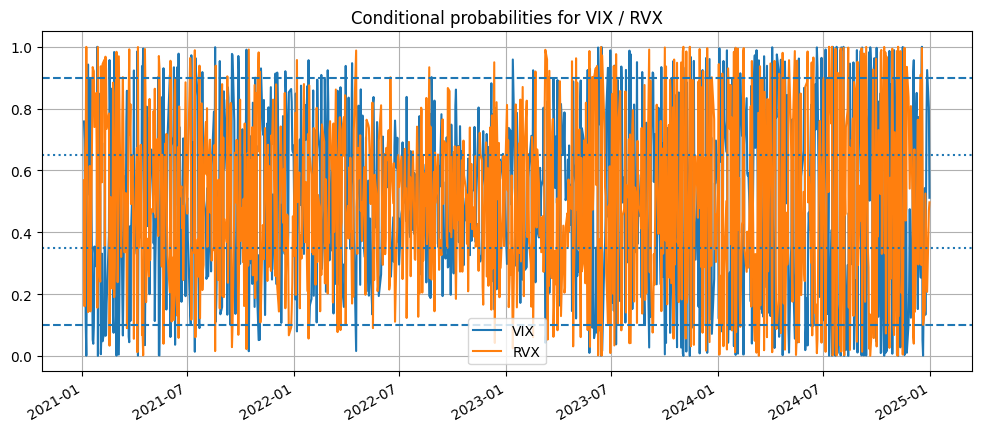

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
probs_trade[["VIX", "RVX"]].plot(ax=ax)
ax.axhline(0.90, ls="--")
ax.axhline(0.10, ls="--")
ax.axhline(0.65, ls=":")
ax.axhline(0.35, ls=":")
ax.set_title("Conditional probabilities for VIX / RVX")
ax.grid(True)
plt.show()

In [20]:
equity, positions, pair_simple = pair_strategy(
    returns_full,
    probs_trade,
    cl=0.90,
    cl_close=0.65
)

print("Equity head:")
display(equity.head())

print("Positions head:")
display(positions.head())

Equity head:


,algo,VIX,RVX
2021-01-04,1.0,1.185495,1.127374
2021-01-05,1.0,1.113846,1.047151
2021-01-06,1.0,1.101978,1.047806
2021-01-07,1.0,0.983297,0.966929
2021-01-08,1.0,0.947692,1.018664


Positions head:


,VIX,RVX
2021-01-04,0.0,0.0
2021-01-05,0.0,0.0
2021-01-06,0.0,0.0
2021-01-07,0.0,0.0
2021-01-08,1.0,-1.0


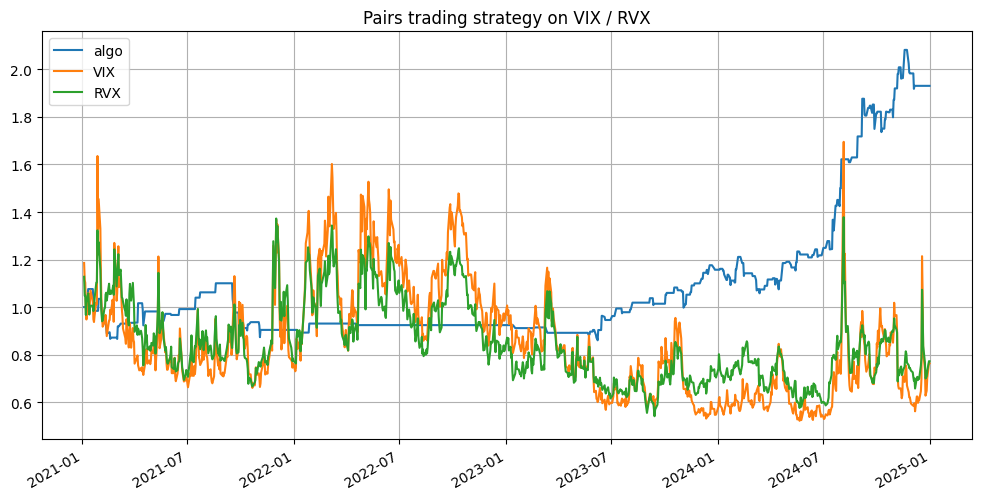

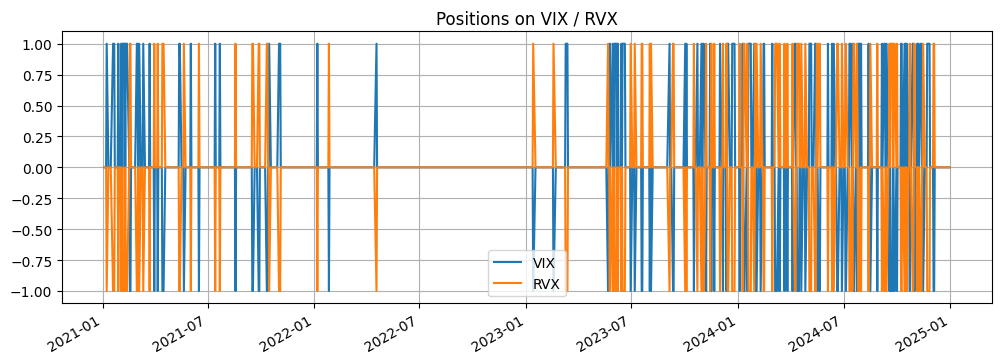

In [21]:
ax = equity.plot(figsize=(12, 6))
ax.set_title("Pairs trading strategy on VIX / RVX")
ax.grid(True)
plt.show()

ax = positions.plot(figsize=(12, 4))
ax.set_title("Positions on VIX / RVX")
ax.grid(True)
plt.show()

In [22]:
metrics = pd.DataFrame({
    "algo": calculate_metrics(equity["algo"]),
    "VIX": calculate_metrics(equity["VIX"]),
    "RVX": calculate_metrics(equity["RVX"])
}).T

print("Performance metrics:")
display(metrics)

Performance metrics:


,Total return,APR,Sharpe,MaxDD
algo,0.931004,0.179394,0.883591,-0.218078
VIX,-0.356693,-0.104714,0.494933,-0.681268
RVX,-0.315423,-0.090646,0.330390,-0.606155


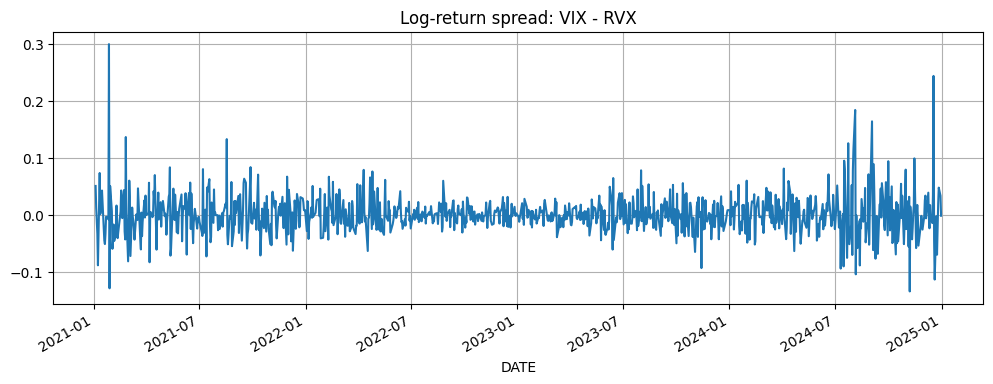

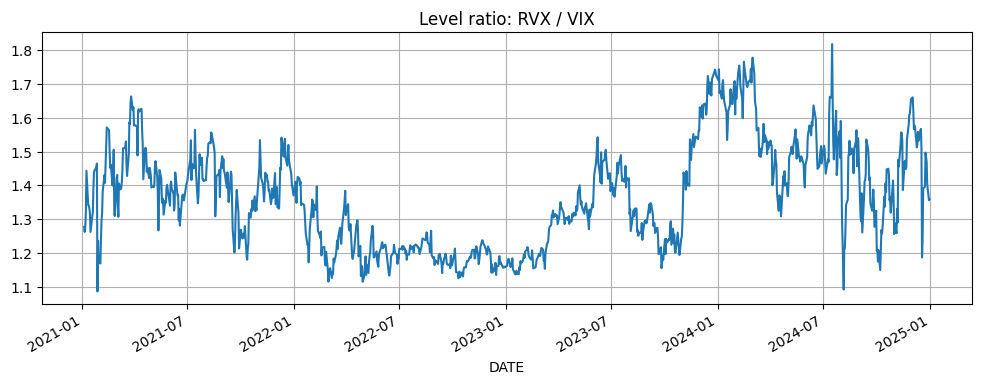

ADF p-value on trade spread: 2.104850166133463e-11
KPSS p-value on trade spread: 0.1


C:\Users\tawaj\AppData\Local\Temp\ipykernel_7688\1988866907.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS p-value on trade spread:", kpss(spread_trade.dropna(), regression="c", nlags="auto")[1])


In [23]:
spread_trade = returns_full.loc[trade_start:trade_end, "VIX"] - returns_full.loc[trade_start:trade_end, "RVX"]
ratio_trade = vol_full.loc[trade_start:trade_end, "RVX"] / vol_full.loc[trade_start:trade_end, "VIX"]

plot_spread(spread_trade, "Log-return spread: VIX - RVX")
plot_spread(ratio_trade, "Level ratio: RVX / VIX")

print("ADF p-value on trade spread:", adfuller(spread_trade.dropna())[1])
print("KPSS p-value on trade spread:", kpss(spread_trade.dropna(), regression="c", nlags="auto")[1])

In [24]:
summary_dict = {
    "Train start": train_start,
    "Train end": train_end,
    "Trade start": trade_start,
    "Trade end": trade_end,
    "Best static copula on train": best_copula_name,
    "Rolling fitting period": fitting_period,
    "Rolling predicting period": predicting_period,
    "Open threshold": 0.90,
    "Close threshold": 0.65,
    "Return correlation": returns_train.corr().loc["VIX", "RVX"],
    "Kendall tau": stats.kendalltau(returns_train["VIX"], returns_train["RVX"])[0],
    "Strategy total return": metrics.loc["algo", "Total return"],
    "Strategy APR": metrics.loc["algo", "APR"],
    "Strategy Sharpe": metrics.loc["algo", "Sharpe"],
    "Strategy MaxDD": metrics.loc["algo", "MaxDD"]
}

summary_df = pd.DataFrame(summary_dict, index=[0]).T
summary_df.columns = ["Value"]

display(summary_df)

,Value
Train start,2010-01-01
Train end,2020-12-31
Trade start,2021-01-01
Trade end,2025-12-31
Best static copula on train,N14
Rolling fitting period,500
Rolling predicting period,100
Open threshold,0.9
Close threshold,0.65
Return correlation,0.902986
